In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/yashasija/tesla-deliveries-dataset-2015-2025/tesla_deliveries_dataset_2015_2025.csv"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df.shape

(2640, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [6]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


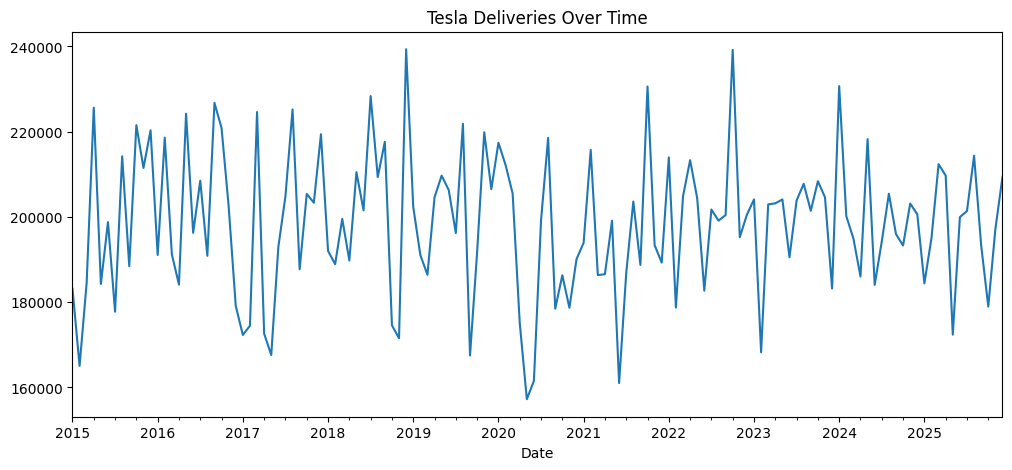

In [9]:
plt.figure(figsize=(12,5))

df.groupby("Date")["Estimated_Deliveries"].sum().plot()

plt.title("Tesla Deliveries Over Time")
plt.show()

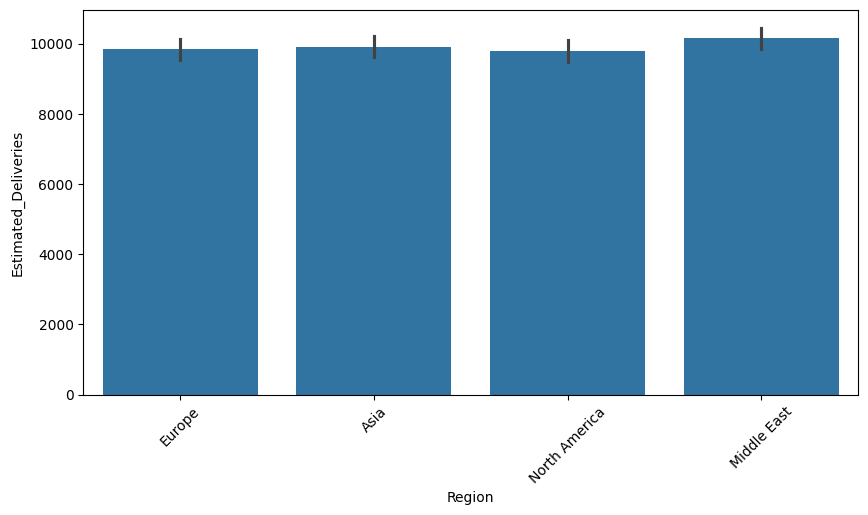

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries"
)

plt.xticks(rotation=45)
plt.show()


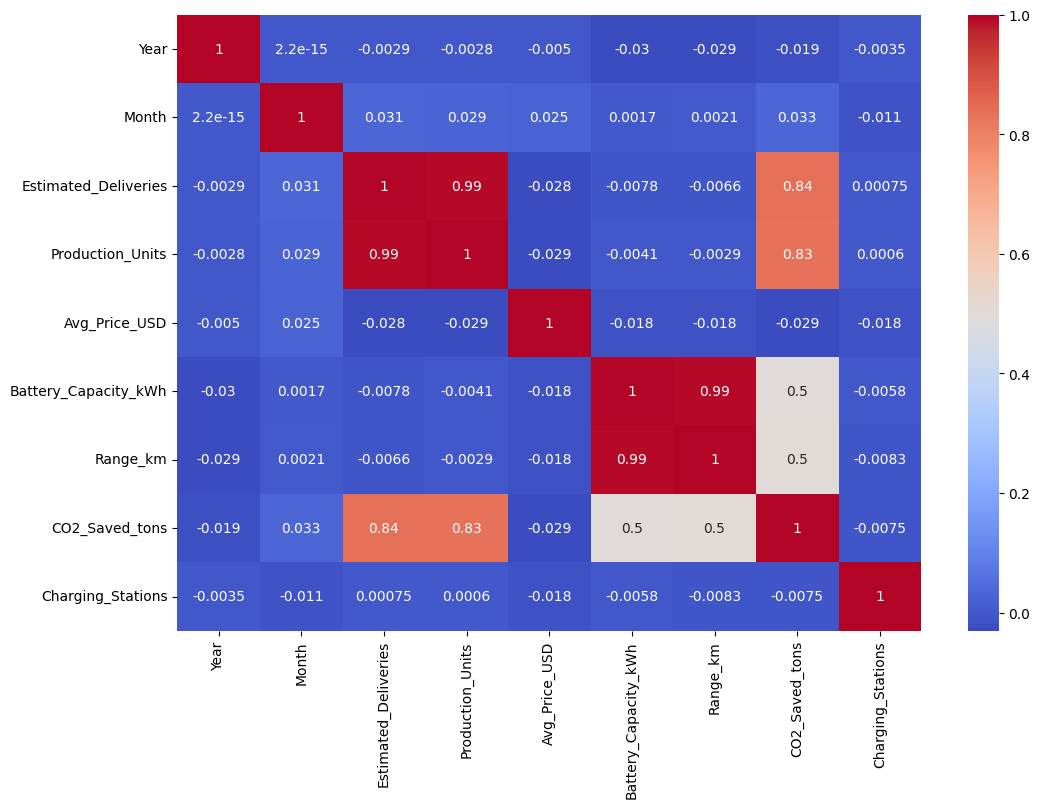

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [12]:
df["Quarter"] = df["Date"].dt.quarter
df["Month_Num"] = df["Date"].dt.month
df["Year_Num"] = df["Date"].dt.year

In [13]:
df["Delivery_Rate"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

In [14]:
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
      .rolling(3)
      .mean()
)

In [15]:
df = df.fillna(0)

In [16]:
y = df["Estimated_Deliveries"]
X = df.drop(
    columns=[
        "Estimated_Deliveries",
        "Date"
    ]
)


In [17]:
categorical_cols = X.select_dtypes(
    include="object"
).columns

numerical_cols = X.select_dtypes(
    exclude="object"
).columns

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            SimpleImputer(strategy="median"),
            numerical_cols
        )
    ]
)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Region', 'Model', 'Source_Type'], dtype='object')),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Quarter', 'Month_Num', 'Year_Num',
       'Delivery_Rate', 'Rolling_Mean_3'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [21]:
predictions = pipeline.predict(X_test)

In [22]:
print("MAE:",
      mean_absolute_error(
          y_test,
          predictions
      ))

MAE: 67.38108901515147


In [23]:
print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              predictions
          )
      ))

RMSE: 111.93726582022943


In [24]:
print("R2 Score:",
      r2_score(
          y_test,
          predictions
      ))

R2 Score: 0.9991594184033732


In [25]:
from sklearn.model_selection import GridSearchCV
params = {
    "model__n_estimators":[100,200,300],
    "model__max_depth":[5,10,15,None]
}
grid = GridSearchCV(
    pipeline,
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Region', 'Model', 'Source_Type'], dtype='object')),
                                                                        ('num',
                                                                         SimpleImputer(strategy='median'),
                                                                         Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Quarter', 'Month_Num', 'Year_Num',
       'Delivery_Rate', 'Rolling_Mean_3'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(n_estimators=200,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 15, None],
                         'model__n_estimators': [100, 200, 300]},
             scoring='r2')

In [26]:
print(grid.best_params_)


{'model__max_depth': None, 'model__n_estimators': 300}


In [27]:
print(grid.best_score_)

0.9981376702141529


In [28]:
ts = df.groupby(
    "Date"
)["Estimated_Deliveries"].sum()

In [29]:
from prophet import Prophet
forecast_df = ts.reset_index()

forecast_df.columns = [
    "ds",
    "y"
]
model = Prophet()

model.fit(
    forecast_df
)

06:14:31 - cmdstanpy - INFO - Chain [1] start processing
06:14:31 - cmdstanpy - INFO - Chain [1] done processing


In [30]:
future = model.make_future_dataframe(
    periods=12,
    freq="ME"
)

In [31]:
forecast = model.predict(
    future
)

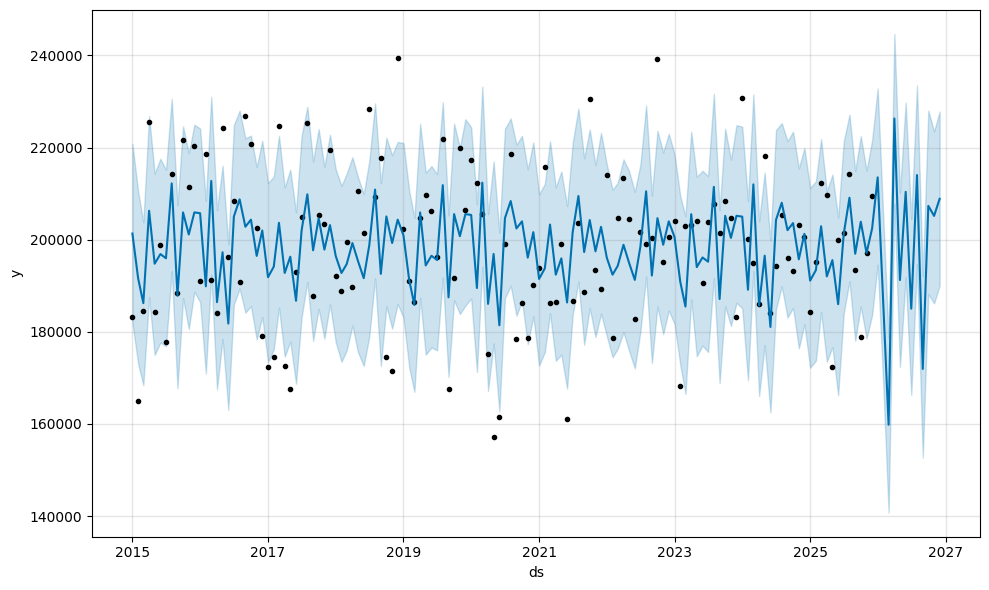

In [32]:
model.plot(forecast)
plt.show()